In [13]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [24]:
# 1️⃣ Load the Iris dataset
df = pd.read_csv('/content/Iris.csv')
iris = datasets.load_iris()
X = iris.data[:, :2]  # We take only the first two features for 2D visualization
y = iris.target

In [15]:
# 2️⃣ Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
# 3️⃣ Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# 4️⃣ Train the KNN classifier with different values of K
k_values = [1, 3, 5, 7, 9]
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)
    print(f'K={k} -> Accuracy: {acc:.2f}')

K=1 -> Accuracy: 0.71
K=3 -> Accuracy: 0.80
K=5 -> Accuracy: 0.80
K=7 -> Accuracy: 0.80
K=9 -> Accuracy: 0.82


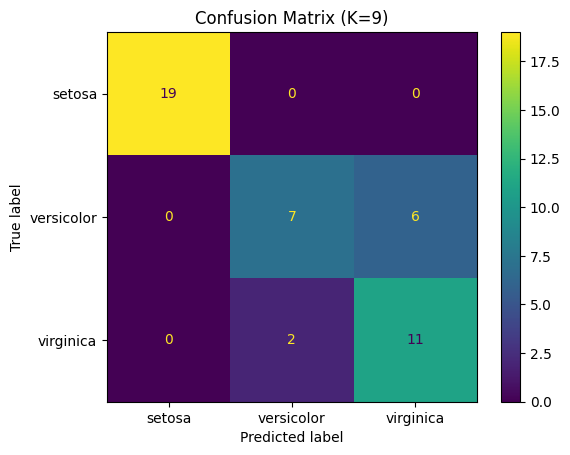

In [18]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title(f'Confusion Matrix (K={k})')
plt.show()

In [19]:
# 5️⃣ Visualize decision boundaries for the best K
best_k = k_values[np.argmax(accuracy_scores)]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=9)

In [20]:
# Create mesh grid
h = .02  # step size in the mesh
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

In [21]:
# Predict on mesh
Z = knn_best.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

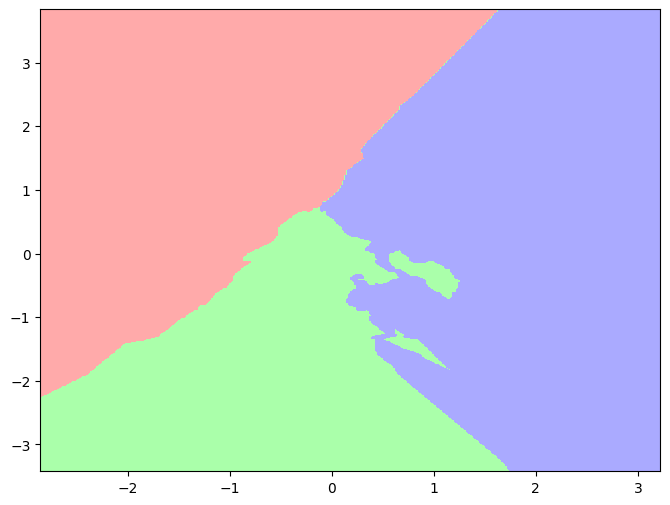

In [22]:
# Plot decision boundary
plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.contourf(xx, yy, Z, cmap=cmap_light)

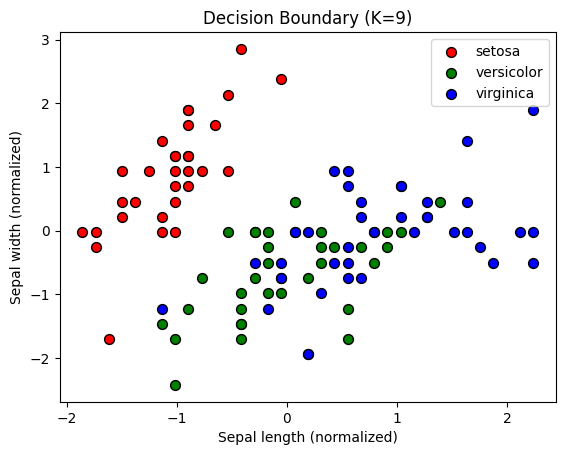

In [23]:
# Plot training points
for i, color in zip(range(len(iris.target_names)), cmap_bold):
    idx = np.where(y_train == i)
    plt.scatter(X_train_scaled[idx, 0], X_train_scaled[idx, 1], c=color, label=iris.target_names[i],
                edgecolor='black', s=50)

plt.xlabel('Sepal length (normalized)')
plt.ylabel('Sepal width (normalized)')
plt.title(f'Decision Boundary (K={best_k})')
plt.legend()
plt.show()